In [1]:
#####################################################
# Imports and Simulation IO
#####################################################

import os 
from MDToolkit.data.objects import Topology, Frame, Simulation, LAMMPS_CustomDump_Reader
from MDToolkit.utils.structure_file_utils import create_elements_dictionary
from MDToolkit.analysis.current import qv_current, qv_current_time_averaged

filedir = "/media/jrjoseph/Elements/projects/training/graphene_water_kcl_ls6/"
filename = "graphene_water_kcl_2.5V_prod1.out"

filepath = os.path.join(filedir, filename)

type_mapping = {
    1 : "Cl",
    2 : "H",
    3 : "O",
    4 : "C",
    5 : "K",
}

charges_dict = {
    1 : -1.0,
    2 : 0.4238,
    3 : -0.8476,
    4 : 0.0,
    5 : 1.0
}

topol = Topology(type_mapping, elements_dict = create_elements_dictionary(), charges_dict = charges_dict)

reader = LAMMPS_CustomDump_Reader(filepath, topol)

simulation = Simulation(filepath, topol, LAMMPS_CustomDump_Reader)

In [2]:
#####################################################
# Time Averaged Current
#####################################################

result = qv_current_time_averaged(simulation)

units = "ev/fs"

print(f"{result['I']:.3f} ± {result['std']:.3f} {units}")

  0%|          | 0/2001 [00:00<?, ?it/s]

-0.000 ± 0.000 ev/fs


  0%|          | 0/2001 [00:00<?, ?it/s]

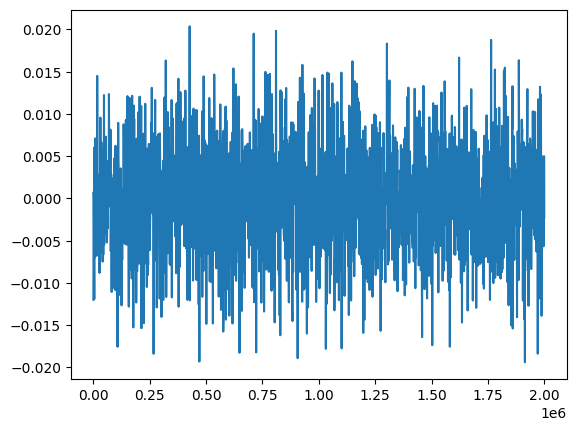

In [4]:
#####################################################
# Current vs Time
#####################################################
from tqdm.auto import  tqdm
import matplotlib.pyplot as plt

I_vec = [1, 0, 0]

I = []
t = []
for frame in tqdm(simulation, total = len(simulation)):
    I.append(qv_current(frame, I_vec))
    t.append(frame.timestep)

plt.plot(t, I)
plt.show()